# Divar Real Estate Analysis — Descriptive Statistics

**Questions:**
- **Q8:** Correlation Matrix of Price, Size, Capacity, Rooms and Location
- **Q9:** Regional Distribution of Properties with Balcony, Elevator, Security Guard, Barbecue and Pool

**Author:** Mahdi Tarrah

**Data:** `data/Divar.csv`

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
#cheak 1000 narrow
df_cheak = pd.read_csv('../data/Divar.csv', nrows=1000)

In [3]:
#cheak datatypes of each columns
df_cheak.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 61 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  1000 non-null   int64  
 1   cat2_slug                   1000 non-null   str    
 2   cat3_slug                   1000 non-null   str    
 3   city_slug                   1000 non-null   str    
 4   neighborhood_slug           438 non-null    str    
 5   created_at_month            1000 non-null   str    
 6   user_type                   288 non-null    str    
 7   description                 1000 non-null   str    
 8   title                       1000 non-null   str    
 9   rent_mode                   330 non-null    str    
 10  rent_value                  328 non-null    float64
 11  rent_to_single              0 non-null      float64
 12  rent_type                   101 non-null    str    
 13  price_mode                  599 non-null    s

In [4]:
#see data
df_cheak.head()

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,...,NaN,4.0,6.0,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
#read all columns we need for Q8
q8_columns = ['price_value','land_size','building_size','regular_person_capacity','rooms_count','location_latitude','location_longitude','city_slug','cat3_slug']
df = pd.read_csv('../data/Divar.csv', usecols=q8_columns)
df.shape

(1000000, 9)

In [6]:
#cheak_nulls
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   cat3_slug                999999 non-null  str    
 1   city_slug                999998 non-null  str    
 2   price_value              568346 non-null  float64
 3   land_size                186396 non-null  float64
 4   building_size            980394 non-null  float64
 5   rooms_count              845899 non-null  str    
 6   regular_person_capacity  29870 non-null   float64
 7   location_latitude        655608 non-null  float64
 8   location_longitude       655608 non-null  float64
dtypes: float64(6), str(3)
memory usage: 68.7 MB


In [7]:
#cheak for impossible value
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price_value,568346.0,1.736537e+10,5.878739e+11,0.000000,1.400000e+09,2.840000e+09,5.900000e+09,1.000000e+14
land_size,186396.0,4.165480e+03,1.218927e+05,1.000000,1.100000e+02,1.950000e+02,2.800000e+02,1.000000e+07
building_size,980394.0,4.440648e+03,1.367118e+05,1.000000,7.500000e+01,1.030000e+02,1.650000e+02,1.000000e+07
regular_person_capacity,29870.0,6.557650e+00,7.698655e+00,1.000000,3.000000e+00,4.000000e+00,7.000000e+00,5.000000e+01
location_latitude,655608.0,3.498211e+01,2.379169e+00,23.626478,3.455355e+01,3.572331e+01,3.630701e+01,4.035806e+01
location_longitude,655608.0,5.162974e+01,3.160920e+00,40.162369,5.067717e+01,5.134579e+01,5.180529e+01,7.451162e+01


In [8]:
#cheak values of rooms_count
df['rooms_count'].value_counts(dropna=False)

rooms_count
دو              404050
یک              192083
NaN             154101
سه              138633
بدون اتاق        75898
چهار             21371
پنج یا بیشتر     13864
Name: count, dtype: int64

In [16]:
#copy
df_q8 = df.copy()

#cheak data

print(df_q8['price_value'].quantile([0.99, 0.999, 0.9999]))
print(df_q8['price_value'].sort_values(ascending=False).head(20))

print(df_q8['land_size'].quantile([0.99, 0.999, 0.9999]))
print(df_q8['land_size'].sort_values(ascending=False).head(20))

print(df_q8['building_size'].quantile([0.99, 0.999, 0.9999]))
print(df_q8['building_size'].sort_values(ascending=False).head(20))


#cleaning data
q8_mapping = {'بدون اتاق':0,'یک':1,'دو':2,'سه':3,'چهار':4,'پنج یا بیشتر':5}

df_q8['rooms_count'] = df_q8['rooms_count'].map(q8_mapping)
df_q8['rooms_count'].value_counts(dropna=False)

df_q8.loc[df_q8['price_value'] <= 0, 'price_value'] = np.nan
df_q8.loc[df_q8['land_size'] <= 0, 'land_size'] = np.nan
df_q8.loc[df_q8['building_size'] <= 0, 'building_size'] = np.nan

columns_cheak_outlier = ['land_size','price_value','building_size']
for column in columns_cheak_outlier:
    print('before:',df_q8[column].isna().sum())
    logs = np.log(df_q8[column])
    Q1 = logs.quantile(0.25)
    Q3 = logs.quantile(0.75)
    IQR = Q3 - Q1
    minimum = Q1 - 1.5*IQR
    maximum = Q3 + 1.5*IQR
    df_q8.loc[~logs.between(minimum, maximum), column] = np.nan
    print('after:',df_q8[column].isna().sum())

df_q8.loc[~((df_q8['location_latitude'].between(25, 40)) & (df_q8['location_longitude'].between(44, 63.5))), ['location_latitude', 'location_longitude']] = np.nan
print(df_q8.isna().sum())

df_q8.describe().T

0.9900    8.500000e+10
0.9990    1.111111e+12
0.9999    1.970000e+13
Name: price_value, dtype: float64
329748    1.000000e+14
116854    1.000000e+14
588194    1.000000e+14
786984    1.000000e+14
931774    1.000000e+14
927290    1.000000e+14
740491    1.000000e+14
6406      9.000000e+13
560251    8.900000e+13
339009    8.397000e+13
306779    8.000086e+13
178219    7.000000e+13
388408    6.400000e+13
9201      6.300000e+13
703415    6.160000e+13
51259     6.000000e+13
209643    5.150000e+13
328774    5.000000e+13
564384    5.000000e+13
60067     5.000000e+13
Name: price_value, dtype: float64
0.9900    4.320650e+03
0.9990    1.100000e+06
0.9999    8.180250e+06
Name: land_size, dtype: float64
176035    10000000.0
145526    10000000.0
535334    10000000.0
534250    10000000.0
229017    10000000.0
905101    10000000.0
901197    10000000.0
336726    10000000.0
171954    10000000.0
173270    10000000.0
481516    10000000.0
449438    10000000.0
734403    10000000.0
236786     9250000.0
331890  

,count,mean,std,min,25%,50%,75%,max
price_value,535564.0,5.088866e+09,6.479189e+09,1.640000e+08,1.500000e+09,2.950000e+09,5.810000e+09,5.100000e+10
land_size,179384.0,2.292650e+02,1.848719e+02,2.800000e+01,1.100000e+02,1.850000e+02,2.600000e+02,1.137000e+03
building_size,887827.0,1.274276e+02,8.525152e+01,2.300000e+01,7.500000e+01,1.000000e+02,1.500000e+02,5.380000e+02
rooms_count,845899.0,1.857061e+00,9.889369e-01,0.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,5.000000e+00
regular_person_capacity,29870.0,6.557650e+00,7.698655e+00,1.000000e+00,3.000000e+00,4.000000e+00,7.000000e+00,5.000000e+01
location_latitude,655561.0,3.498264e+01,2.377957e+00,2.501717e+01,3.455394e+01,3.572332e+01,3.630702e+01,3.980854e+01
location_longitude,655561.0,5.162953e+01,3.160282e+00,4.400128e+01,5.067718e+01,5.134577e+01,5.180507e+01,6.284333e+01


In [17]:
q8_cols = ['price_value','land_size','building_size','regular_person_capacity','rooms_count','location_latitude','location_longitude']
pair_counts = pd.DataFrame(index=q8_cols, columns=q8_cols)

for a in q8_cols:
    for b in q8_cols:
        both = (df_q8[a].notna()) & (df_q8[b].notna())
        pair_counts.loc[a, b] = both.sum()

pair_counts


,price_value,land_size,building_size,regular_person_capacity,rooms_count,location_latitude,location_longitude
price_value,535564,108086,493000,0,432391,352058,352058
land_size,108086,179384,173862,0,179384,109401,109401
building_size,493000,173862,887827,23025,790574,585931,585931
regular_person_capacity,0,0,23025,29870,29870,19448,19448
rooms_count,432391,179384,790574,29870,845899,559277,559277
location_latitude,352058,109401,585931,19448,559277,655561,655561
location_longitude,352058,109401,585931,19448,559277,655561,655561


                         price_value  land_size  building_size  \
price_value                 1.000000   0.225383       0.218375   
land_size                   0.225383   1.000000       0.331325   
building_size               0.218375   0.331325       1.000000   
regular_person_capacity          NaN        NaN       0.223118   
rooms_count                 0.349004   0.203978       0.560222   
location_latitude           0.024414   0.058515      -0.061798   
location_longitude         -0.002199   0.033481       0.025758   

                         regular_person_capacity  rooms_count  \
price_value                                  NaN     0.349004   
land_size                                    NaN     0.203978   
building_size                           0.223118     0.560222   
regular_person_capacity                 1.000000     0.344266   
rooms_count                             0.344266     1.000000   
location_latitude                      -0.046471    -0.021110   
location_longitu

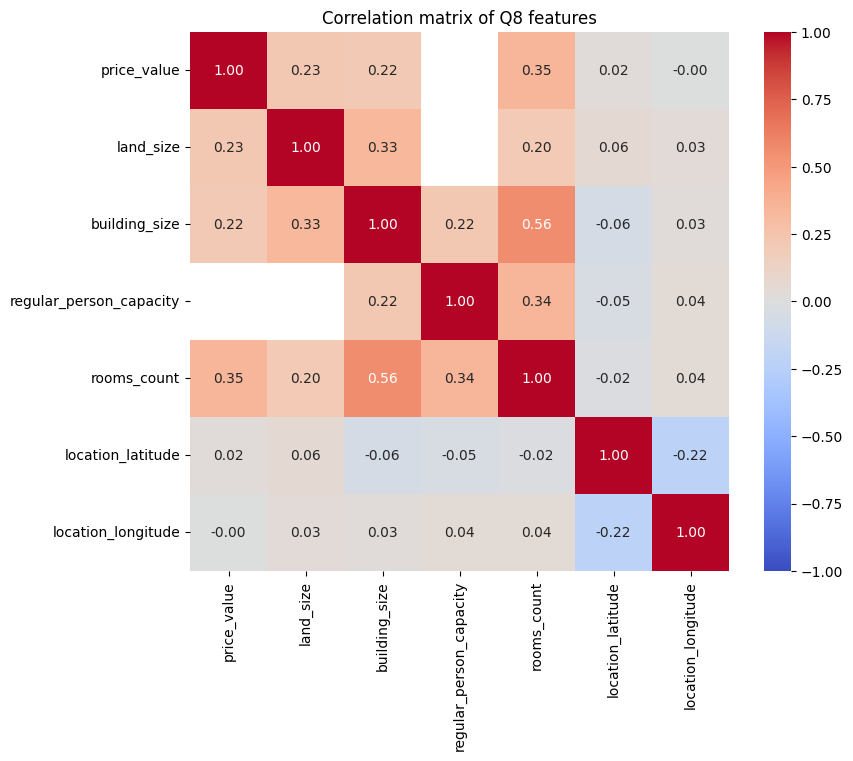

In [19]:
corr_matrix = df_q8[q8_cols].corr()
print(corr_matrix)

plt.figure(figsize=(9, 7))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',vmin=-1, vmax=1, square=True)

plt.title('Correlation matrix of Q8 features')
plt.show()